In [26]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
%load_ext autoreload
%autoreload 2
import matrix_utils as mu
import warnings 
warnings.simplefilter('ignore')
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def incidence_to_bipartite_graph(I, vertex_prefix="v", edge_prefix="e"):
    """
    Build a bipartite incidence graph from an incidence matrix I.

    Parameters
    ----------
    I : np.ndarray
        Incidence matrix of shape (n_vertices, n_hyperedges).
        Nonzero entries mean incidence.
    vertex_prefix : str
        Prefix for vertex-node names.
    edge_prefix : str
        Prefix for hyperedge-node names.

    Returns
    -------
    G : nx.Graph
        Bipartite incidence graph.
    vertex_nodes : list
        List of vertex-node names.
    edge_nodes : list
        List of hyperedge-node names.
    """
    I = np.asarray(I)
    n_vertices, n_edges = I.shape

    G = nx.Graph()

    vertex_nodes = [f"{vertex_prefix}{i+1}" for i in range(n_vertices)]
    edge_nodes = [f"{edge_prefix}{j+1}" for j in range(n_edges)]

    G.add_nodes_from(vertex_nodes, bipartite=0)
    G.add_nodes_from(edge_nodes, bipartite=1)

    rows, cols = np.nonzero(I)   # all nonzero incidences
    for i, j in zip(rows, cols):
        G.add_edge(vertex_nodes[i], edge_nodes[j], value=I[i, j])

    return G, vertex_nodes, edge_nodes

def plot_hypergraph_incidence(
    I,
    figsize=(12, 10),
    node_size_vertices=20,
    node_size_edges=20,
    with_labels=False,
    only_largest_component=False,
    layout="spring",
    seed=42
):
    """
    Plot a hypergraph through its bipartite incidence graph.
    """
    G, vertex_nodes, edge_nodes = incidence_to_bipartite_graph(I)

    if only_largest_component and len(G) > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
        vertex_nodes = [n for n in vertex_nodes if n in G]
        edge_nodes = [n for n in edge_nodes if n in G]

    if layout == "bipartite":
        pos = nx.bipartite_layout(G, vertex_nodes)
    elif layout == "spring":
        pos = nx.spring_layout(G, seed=seed)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G)
    else:
        raise ValueError("layout must be 'bipartite', 'spring', or 'kamada_kawai'")

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=vertex_nodes,
        node_color="lightblue",
        node_size=node_size_vertices
    )
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=edge_nodes,
        node_color="lightgreen",
        node_size=node_size_edges
    )

    nx.draw_networkx_edges(G, pos, alpha=0.4, width=0.5)

    if with_labels:
        nx.draw_networkx_labels(G, pos, font_size=8)

    plt.axis("off")
    plt.show()
def plot_signed_hypergraph_incidence(I, figsize=(12, 10), seed=42):
    G, vertex_nodes, edge_nodes = incidence_to_bipartite_graph(I)
    pos = nx.bipartite_layout(G, vertex_nodes)

    plt.figure(figsize=figsize)

    nx.draw_networkx_nodes(G, pos, nodelist=vertex_nodes, node_color="lightblue", node_size=30)
    nx.draw_networkx_nodes(G, pos, nodelist=edge_nodes, node_color="lightgreen", node_size=30)

    positive_edges = [(u, v) for u, v, d in G.edges(data=True) if d["value"] == 1]
    negative_edges = [(u, v) for u, v, d in G.edges(data=True) if d["value"] == -1]

    nx.draw_networkx_edges(G, pos, edgelist=positive_edges, edge_color="green", style="solid", width=0.8)
    nx.draw_networkx_edges(G, pos, edgelist=negative_edges, edge_color="red", style="dotted", width=0.8)

    plt.axis("off")
    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


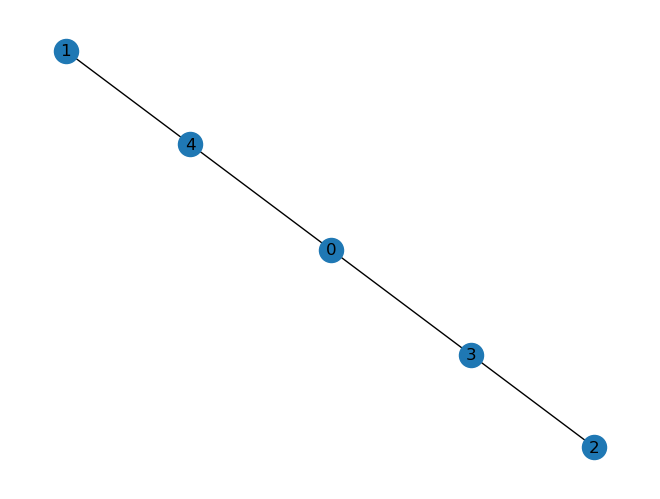

In [6]:
I = np.array([[1, 1],
       [0, 1],
       [1, 0]])

A = mu.bipartite_incidence_adjacency(I)

G = nx.from_numpy_array(A)

nx.draw(G, with_labels=True)
plt.show()

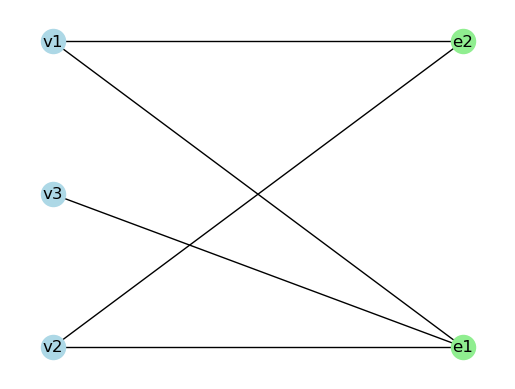

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

I = np.array([
    [1, 1],
    [1, 1],
    [1, 0]
])

n_vertices, n_edges = I.shape

G = nx.Graph()

vertex_nodes = [f"v{i+1}" for i in range(n_vertices)]
edge_nodes = [f"e{j+1}" for j in range(n_edges)]

G.add_nodes_from(vertex_nodes, bipartite=0)
G.add_nodes_from(edge_nodes, bipartite=1)

for i in range(n_vertices):
    for j in range(n_edges):
        if I[i, j] == 1:
            G.add_edge(f"v{i+1}", f"e{j+1}")

# Extract the two parts
top = [n for n, d in G.nodes(data=True) if d["bipartite"] == 0]
bottom = [n for n, d in G.nodes(data=True) if d["bipartite"] == 1]

# Automatic bipartite layout
pos = nx.bipartite_layout(G, top)

# Draw each part with its own color
nx.draw_networkx_nodes(G, pos, nodelist=top, node_color="lightblue", label="vertices")
nx.draw_networkx_nodes(G, pos, nodelist=bottom, node_color="lightgreen", label="hyperedges")
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

#plt.legend()
plt.axis("off")
plt.show()

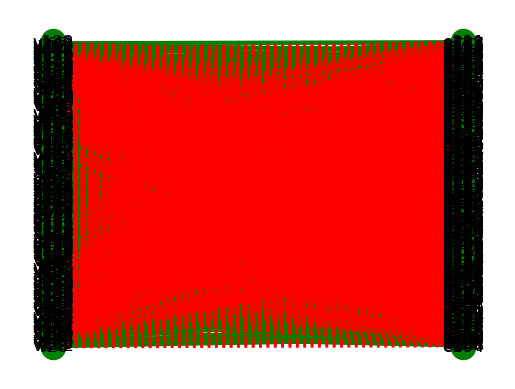

In [20]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

I = np.array([
    [ 1, -1],
    [ 1,  1],
    [-1,  0]
])
I = ahorn.incidence("senate committees")

n_vertices, n_edges = I.shape

G = nx.Graph()

vertex_nodes = [f"v{i+1}" for i in range(n_vertices)]
edge_nodes = [f"e{j+1}" for j in range(n_edges)]

G.add_nodes_from(vertex_nodes, bipartite=0)
G.add_nodes_from(edge_nodes, bipartite=1)

# Add only nonzero incidences, and keep the sign
for i in range(n_vertices):
    for j in range(n_edges):
        if I[i, j] != 0:
            G.add_edge(f"v{i+1}", f"e{j+1}", sign=I[i, j])

top = [n for n, d in G.nodes(data=True) if d["bipartite"] == 0]
bottom = [n for n, d in G.nodes(data=True) if d["bipartite"] == 1]

pos = nx.bipartite_layout(G, top)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=top, node_color="green", label="vertices")
nx.draw_networkx_nodes(G, pos, nodelist=bottom, node_color="green", label="hyperedges")

# Split edges by sign
positive_edges = [(u, v) for u, v, d in G.edges(data=True) if d["sign"] == 1]
negative_edges = [(u, v) for u, v, d in G.edges(data=True) if d["sign"] == -1]

# Draw edges with different styles
nx.draw_networkx_edges(
    G, pos,
    edgelist=positive_edges,
    edge_color="green",
    style="solid",
    width=2
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=negative_edges,
    edge_color="red",
    style="dotted",
    width=2
)

nx.draw_networkx_labels(G, pos)

plt.axis("off")
plt.show()

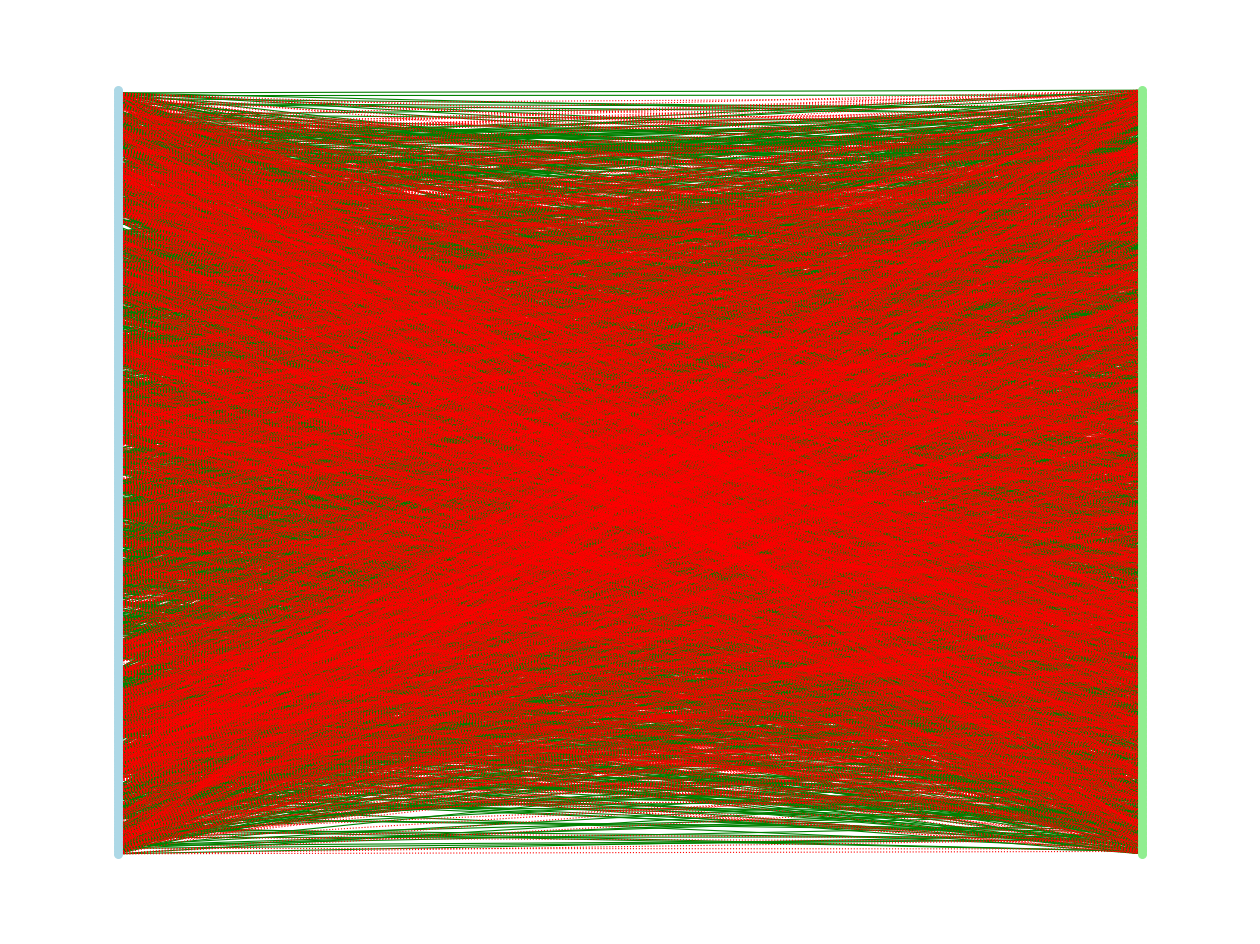

In [32]:
I = ahorn.incidence("senate committees")
plot_signed_hypergraph_incidence(
    I,
    figsize=(16, 12),
    #node_size_vertices=5,
    #node_size_edges=5,
   # with_labels=False,
    #only_largest_component=True,
    #layout="bipartite"
)